# Breast Cancer Survival Analysis
## Notebook 1 — Exploratory Data Analysis

This notebook loads both clinical cohorts (SEER and METABRIC), computes descriptive statistics, and visualises the distribution of and relationships between variables.

**Outputs used in:** `02_hypothesis_testing.ipynb`, `03_machine_learning.ipynb`

---

### Contents
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Descriptive Statistics](#2-descriptive-statistics)
3. [Pairwise Scatter Matrices](#3-pairwise-scatter-matrices)
4. [Ordinal Variable Distributions](#4-ordinal-variable-distributions)
5. [Correlation Heatmaps](#5-correlation-heatmaps)
6. [Violin Plots](#6-violin-plots)
7. [Key Takeaways](#7-key-takeaways)

---
## 1. Setup & Data Loading

> ⚠️ Make sure `DATA_PATH` below points to your local copy of the dataset.
> See `README.md → Datasets` for download instructions.

In [1]:
# ── Working directory ──────────────────────────────────────────────────────────
# Notebooks run relative to where Jupyter was launched, not where the notebook
# lives. This moves to the project root so data/ paths resolve correctly.
import os
try:
    notebook_dir = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    notebook_dir = os.path.abspath('')
os.chdir(notebook_dir)
#print('Working directory:', os.getcwd())

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# ── Style ──────────────────────────────────────────────────────────────────────
PALETTE    = {'SEER': '#2C7BB6', 'METABRIC': '#D7191C'}
BG_COLOR   = '#F8F9FA'
GRID_COLOR = '#E0E0E0'

plt.rcParams.update({
    'figure.facecolor': BG_COLOR, 'axes.facecolor': BG_COLOR,
    'axes.edgecolor': '#CCCCCC', 'axes.grid': True,
    'grid.color': GRID_COLOR, 'grid.linestyle': '--', 'grid.linewidth': 0.6,
    'axes.labelsize': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'font.family': 'DejaVu Sans',
})

# ── Config ─────────────────────────────────────────────────────────────────────
# Update this to point to your local copy of the dataset
DATA_PATH = 'data/clean_data_breast_cancer.xlsx'

COLUMN_RENAME = {
    'Survival Months': 'Survival_Months', 'Regional Node 1': 'Regional_Node',
    'Estrogen Status': 'Estrogen', 'Progesterone Status': 'Progesterone',
    'Tumor Size': 'Tumor_Size', 'T Stage': 'T_Stage',
}

In [2]:
# ── Data loading ───────────────────────────────────────────────────────────────
def load_data(path):
    try:
        seer     = pd.read_excel(path, sheet_name='SEER')
        metabric = pd.read_excel(path, sheet_name='METABRIC')
    except FileNotFoundError:
        raise FileNotFoundError(
            f"Data file not found at '{path}'. "
            "See README.md -> Datasets for download instructions."
        )
    print(f'SEER:     {seer.shape[0]:,} rows x {seer.shape[1]} columns')
    print(f'METABRIC: {metabric.shape[0]:,} rows x {metabric.shape[1]} columns')
    return seer, metabric

def combine_datasets(seer, metabric):
    seer, metabric = seer.copy(), metabric.copy()
    seer['Population'], metabric['Population'] = 0, 1
    combined = pd.concat([seer, metabric], ignore_index=True)
    return combined.rename(columns=COLUMN_RENAME)

def print_descriptive_stats(df, label):
    print(f"\n{'-'*60}\n  Descriptive Statistics: {label}\n{'-'*60}")
    print(df.describe().round(2).to_string())

# ── Plot helpers ───────────────────────────────────────────────────────────────
def plot_pairplot(df, label, color):
    cols = [c for c in ['Age', 'Tumor Size', 'Regional Node 1', 'Survival Months'] if c in df.columns]
    g = sns.pairplot(df[cols], plot_kws={'s': 4, 'alpha': 0.4, 'color': color},
                     diag_kws={'color': color, 'alpha': 0.6})
    g.figure.suptitle(f'{label}: Pairwise Scatter Matrix', y=1.02, fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

def plot_histograms(df, cols, label, color):
    fig, axes = plt.subplots(1, len(cols), figsize=(5 * len(cols), 4))
    if len(cols) == 1: axes = [axes]
    for ax, col in zip(axes, cols):
        ax.hist(df[col].dropna(), bins=20, color=color, alpha=0.75, edgecolor='white')
        ax.set_title(f'{label}: {col}'); ax.set_xlabel(col); ax.set_ylabel('Frequency')
    plt.suptitle(f'{label} - Ordinal Variable Distributions', fontweight='bold')
    plt.tight_layout(); plt.show()

def plot_heatmap(df, label):
    corr = df.select_dtypes(include='number').corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, linewidths=0.4, annot_kws={'size': 8}, ax=ax)
    ax.set_title(f'{label} - Correlation Heatmap', pad=12)
    plt.tight_layout(); plt.show()

def plot_violins(df, cat_vars, num_vars, label, color):
    n_rows, n_cols = len(num_vars), len(cat_vars)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
    for r, num_var in enumerate(num_vars):
        for c, cat_var in enumerate(cat_vars):
            ax = axes[r][c] if n_rows > 1 else axes[c]
            sns.violinplot(data=df, x=cat_var, y=num_var, color=color, alpha=0.7, ax=ax)
            ax.set_title(f'{num_var} vs {cat_var}', fontsize=9)
            ax.set_xlabel(''); ax.set_ylabel(num_var if c == 0 else '')
    fig.suptitle(f'{label} - Violin Plots', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

In [3]:
seer, metabric = load_data(DATA_PATH)

SEER:     4,005 rows x 9 columns
METABRIC: 1,354 rows x 9 columns


---
## 2. Descriptive Statistics

We start with a high-level summary of each cohort to understand the range, central tendency, and spread of every variable before plotting anything.

In [4]:
print_descriptive_stats(seer, 'SEER')


------------------------------------------------------------
  Descriptive Statistics: SEER
------------------------------------------------------------
           Age  T Stage    Grade  Tumor Size  Estrogen Status  Progesterone Status  Regional Node 1  Survival Months   Status
count  4005.00  4005.00  4005.00     4005.00          4005.00              4005.00          4005.00          4005.00  4005.00
mean     53.98     1.78     2.14       30.41             0.93                 0.83             4.15            71.33     0.85
std       8.95     0.76     0.63       21.08             0.25                 0.38             5.11            22.87     0.36
min      30.00     1.00     1.00        1.00             0.00                 0.00             1.00             1.00     0.00
25%      47.00     1.00     2.00       16.00             1.00                 1.00             1.00            56.00     1.00
50%      54.00     2.00     2.00       25.00             1.00                 1.00        

**SEER observations:**
- Average age ~54, consistent with breast cancer risk rising after 35
- T Stage average 1.78 — tumours generally localised
- Grade average 2.14 — cells tend to replicate abnormally
- Estrogen positive in 93% of patients, progesterone in 83% — suggests most are candidates for hormone therapy
- 85% of patients have Status = Alive — class imbalance to keep in mind for ML

In [5]:
print_descriptive_stats(metabric, 'METABRIC')


------------------------------------------------------------
  Descriptive Statistics: METABRIC
------------------------------------------------------------
           Age  T Stage    Grade  Tumor Size  Estrogen Status  Progesterone Status  Regional Node 1  Survival Months   Status
count  1354.00  1354.00  1354.00     1354.00          1354.00              1354.00          1354.00          1354.00  1354.00
mean     60.41     1.76     2.44       25.86             0.77                 0.52             1.90           127.14     0.44
std      12.99     0.62     0.64       14.97             0.42                 0.50             3.93            78.02     0.50
min      21.93     0.00     1.00        1.00             0.00                 0.00             0.00             0.10     0.00
25%      50.71     1.00     2.00       17.00             1.00                 0.00             0.00            61.50     0.00
50%      61.02     2.00     3.00       22.00             1.00                 1.00    

**METABRIC observations:**
- Average age ~60 — 6 years older than SEER on average, and age range extends to 96
- Estrogen positive in only 77% of patients, progesterone in 52% — notably lower than SEER
- 56% of patients have Status = Dead — almost inverted class distribution compared to SEER
- Survival Months maximum is 351 (29 years) vs 107 in SEER — the study window is much longer

> The differences in estrogen/progesterone rates and survival proportions between cohorts will be central to the hypothesis tests in Notebook 2.

---
## 3. Pairwise Scatter Matrices

Pairwise scatter plots let us spot linear relationships between continuous variables at a glance. Diagonal panels show the univariate distribution of each variable.

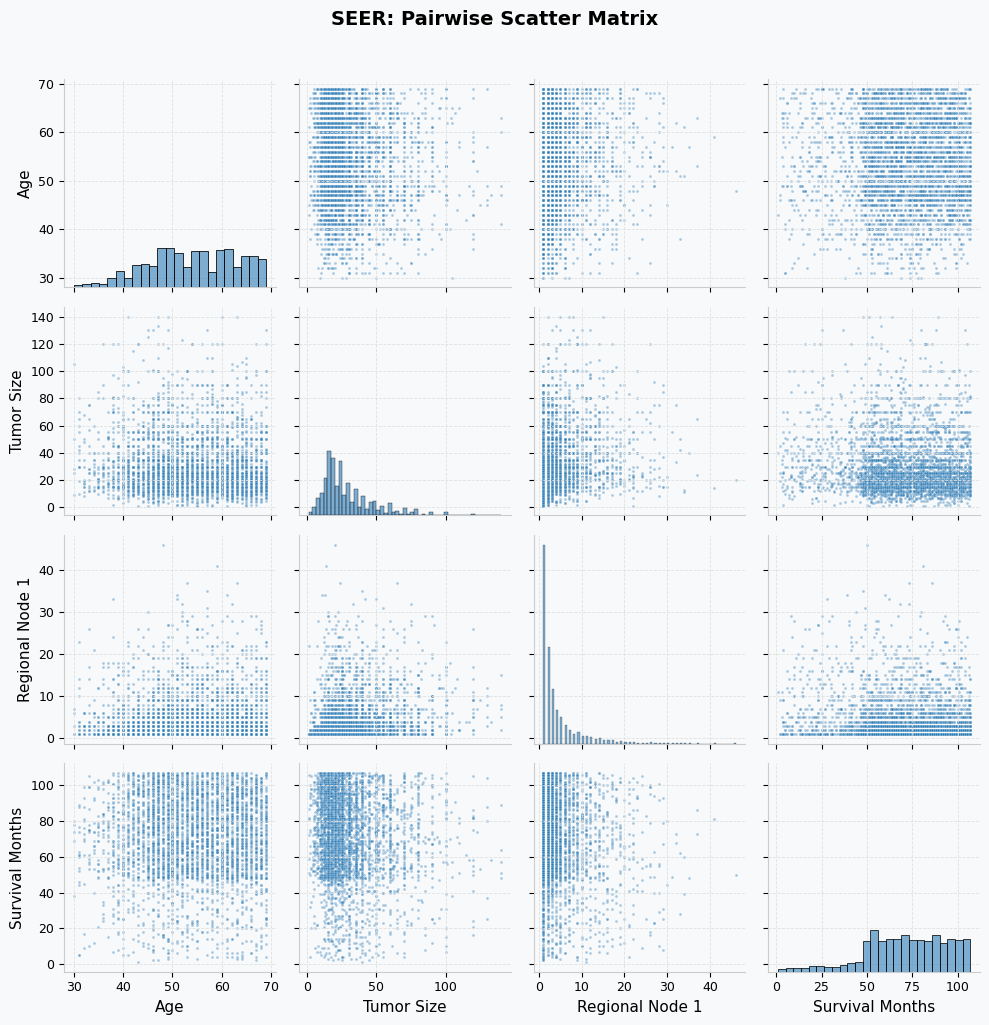

In [6]:
plot_pairplot(seer, 'SEER', PALETTE['SEER'])

**SEER:** Tumor Size is the only variable approximating a normal distribution. Age and Survival Months are more spread out. No strong pairwise linear relationships are visible, which is expected given the low correlations we will see in the heatmap.

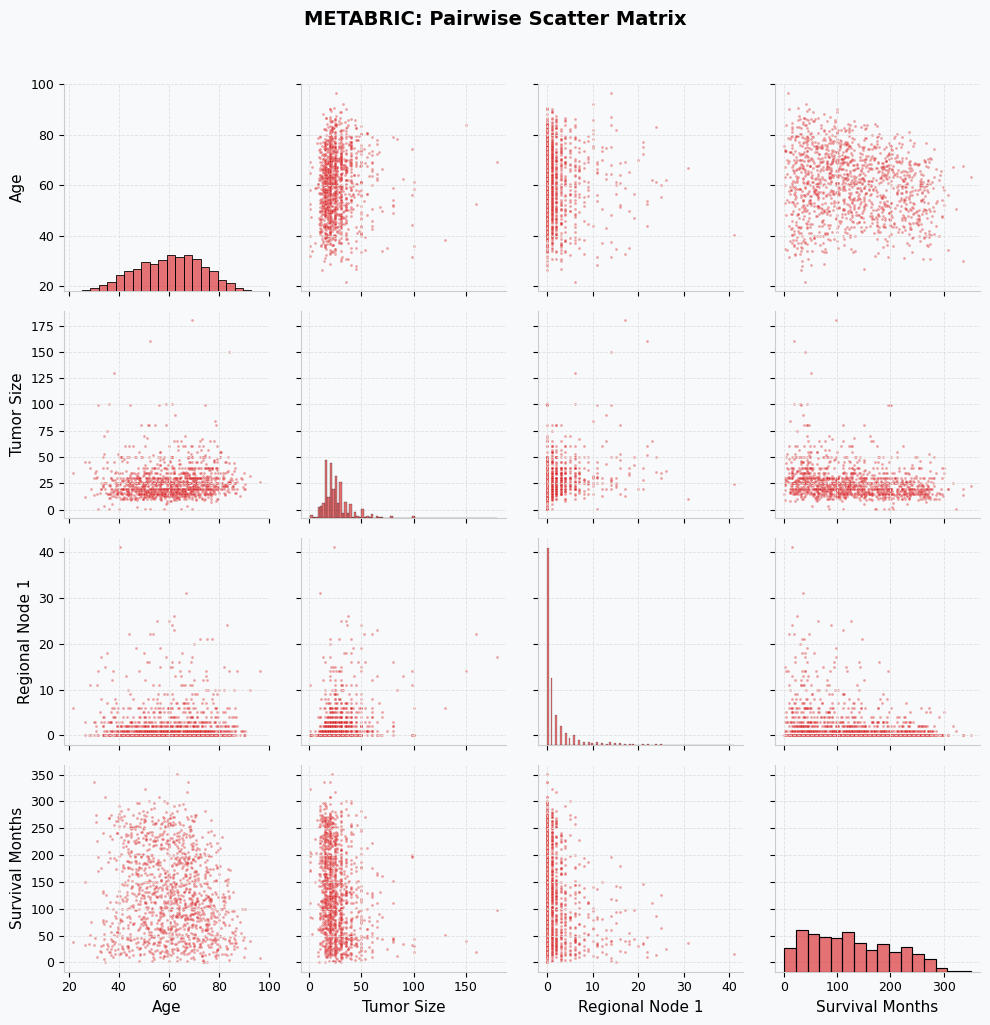

In [7]:
plot_pairplot(metabric, 'METABRIC', PALETTE['METABRIC'])

**METABRIC:** Age now approximates a normal distribution. Regional Node is strongly right-skewed with high concentration at 0. Survival Months is more spread out than in SEER, reflecting the longer study window.

---
## 4. Ordinal Variable Distributions

T Stage and Grade are ordinal variables that would not be meaningful in a pairwise scatter plot. We plot them as histograms to see their frequency distribution.

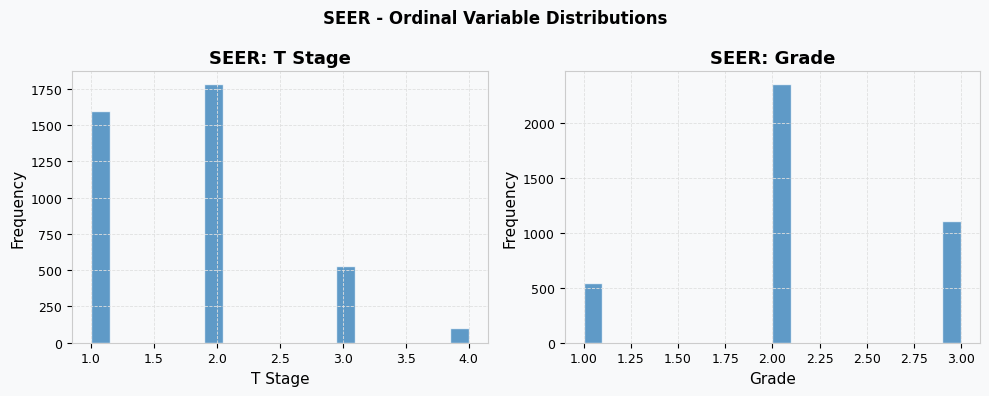

In [8]:
plot_histograms(seer, ['T Stage', 'Grade'], 'SEER', PALETTE['SEER'])

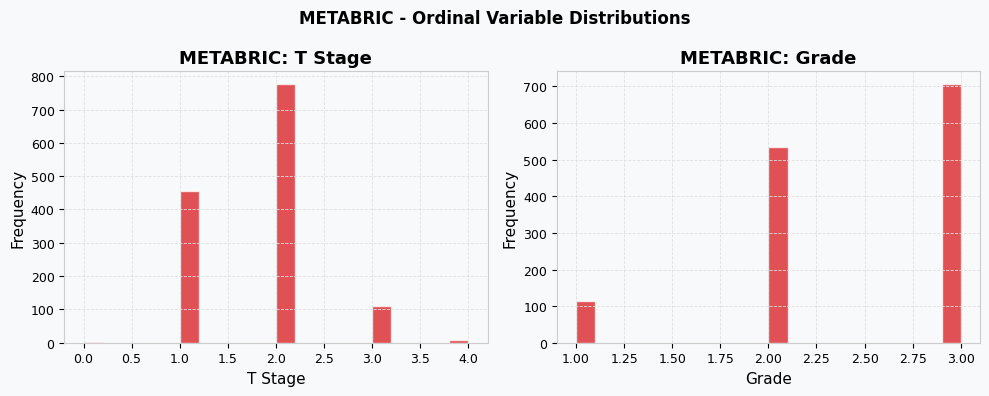

In [9]:
plot_histograms(metabric, ['T Stage', 'Grade'], 'METABRIC', PALETTE['METABRIC'])

**Both cohorts:** T Stage is concentrated at 1-2, consistent with the mean of ~1.75. Grade skews higher in METABRIC (more Grade 3 observations), suggesting more aggressive tumour cell behaviour on average.

---
## 5. Correlation Heatmaps

The correlation matrix tells us two things: which variables are most associated with our targets (Survival Months, Status), and which variables are correlated with each other — the latter is important for avoiding collinearity in regression models.

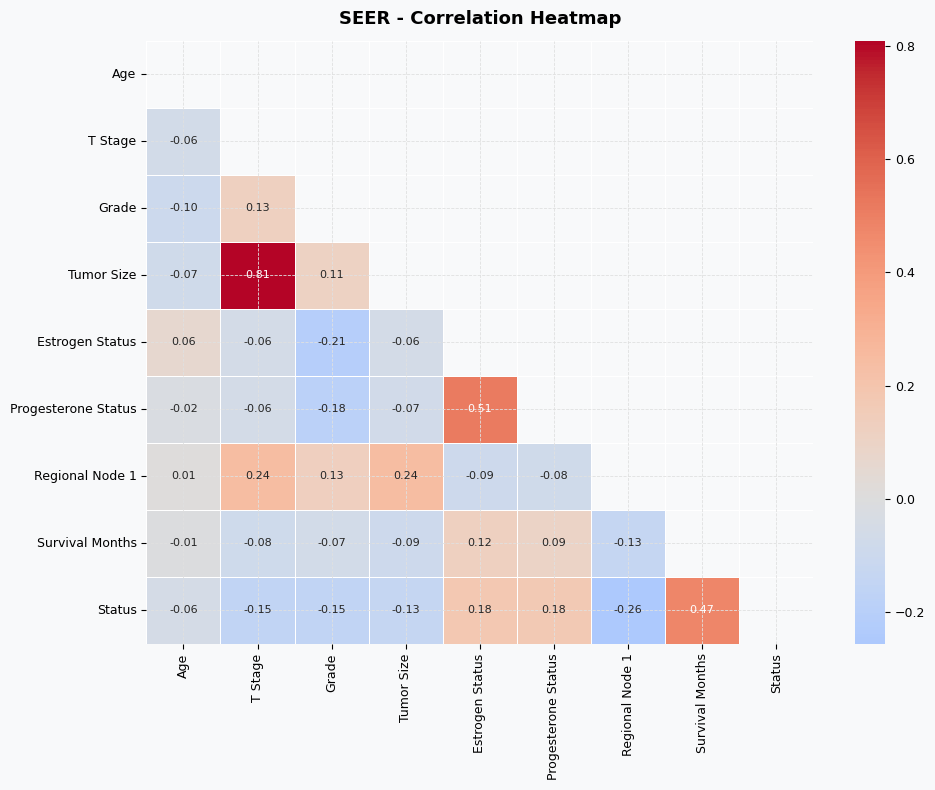

In [10]:
plot_heatmap(seer, 'SEER')

**SEER:** The strongest correlates of Status are Regional Node (-0.26), followed by Estrogen and Progesterone Status (~0.18 each). T Stage and Tumor Size are strongly correlated (0.81) — including both in a regression model risks collinearity.

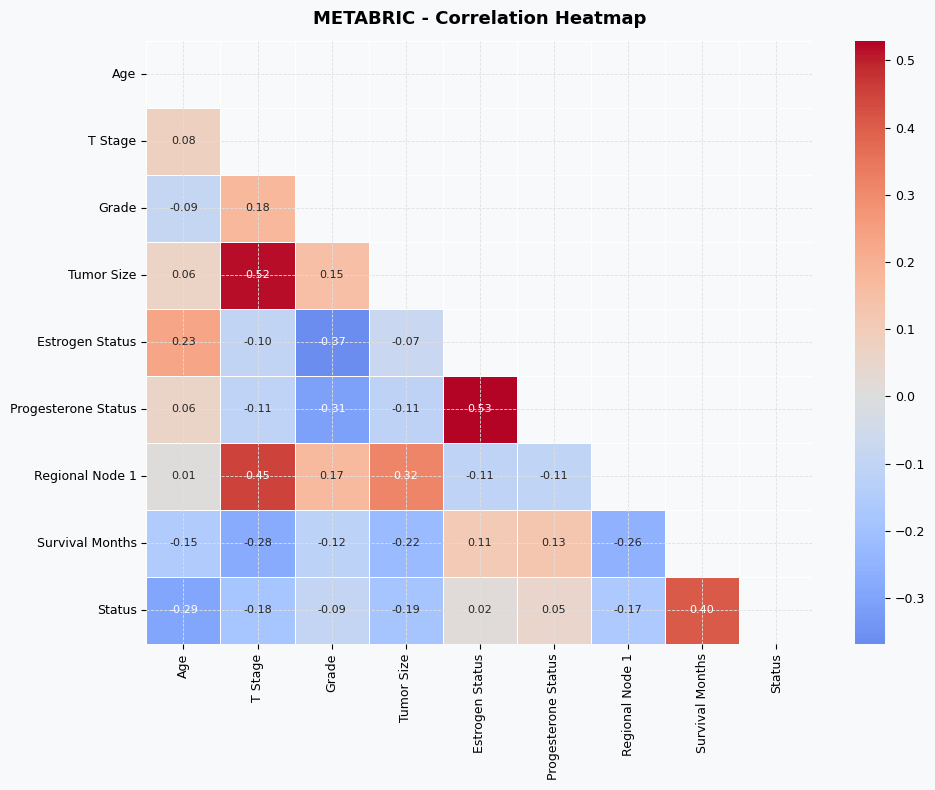

In [11]:
plot_heatmap(metabric, 'METABRIC')

**METABRIC:** Age is now the strongest correlate of Status (-0.29), followed by T Stage and Regional Nodes. T Stage and Tumor Size remain strongly correlated (0.52). Estrogen and Progesterone are correlated with each other (0.53) — we should avoid including both together in regression models.

---
## 6. Violin Plots

Violin plots combine a boxplot summary with a kernel density estimate, making them more informative than boxplots for skewed distributions. We focus on variables most relevant to the hypothesis tests.

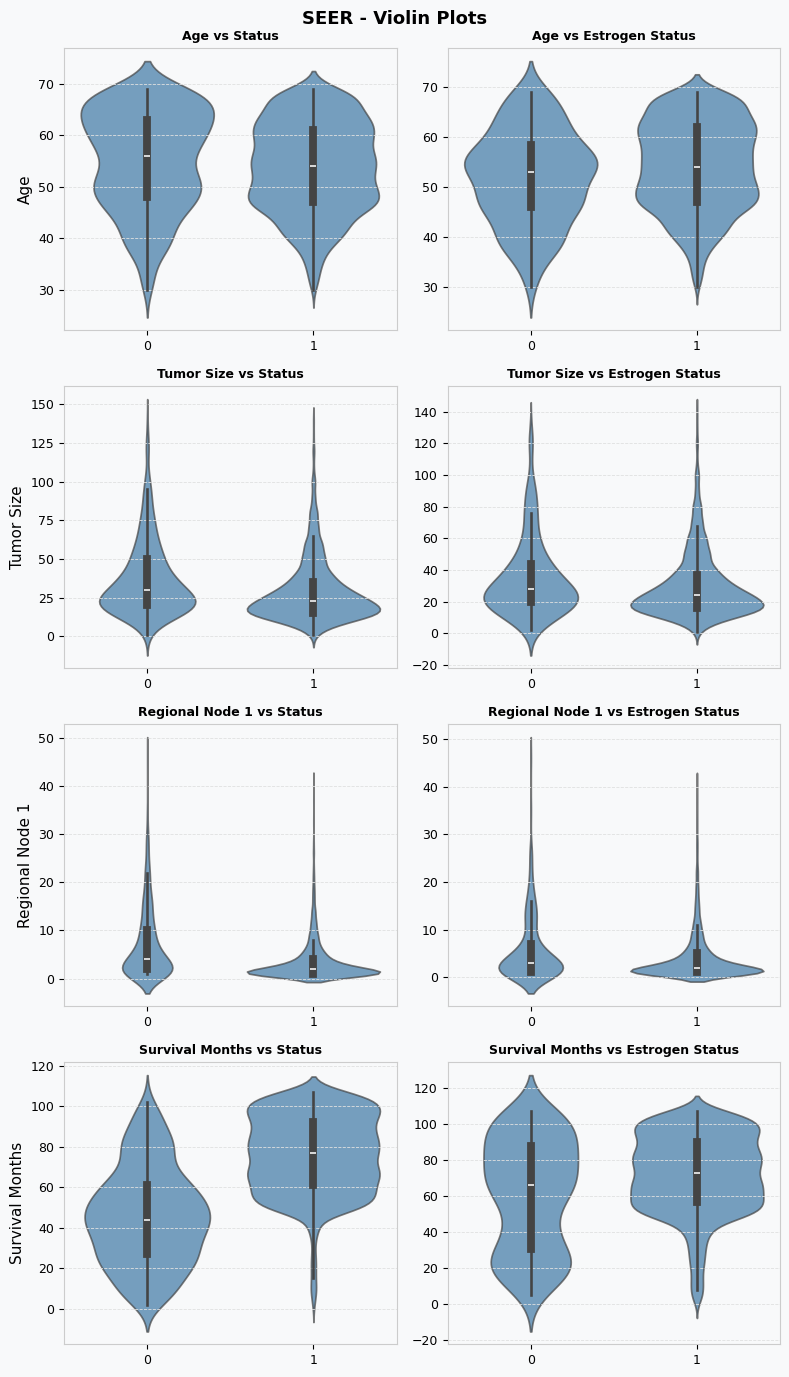

In [12]:
cat_vars = ['Status', 'Estrogen Status']
num_vars = ['Age', 'Tumor Size', 'Regional Node 1', 'Survival Months']

plot_violins(seer, cat_vars, num_vars, 'SEER', PALETTE['SEER'])

**SEER key observations:**
- Patients with Status = Dead tend to have ~3-4 more positive regional nodes than those alive
- Estrogen-negative patients are concentrated around age 50-60; positive patients spread from 45-70
- Positive estrogen receptor patients have smaller tumours on average
- Patients who die have tumour sizes around 25mm+; survivors cluster around 12-15mm

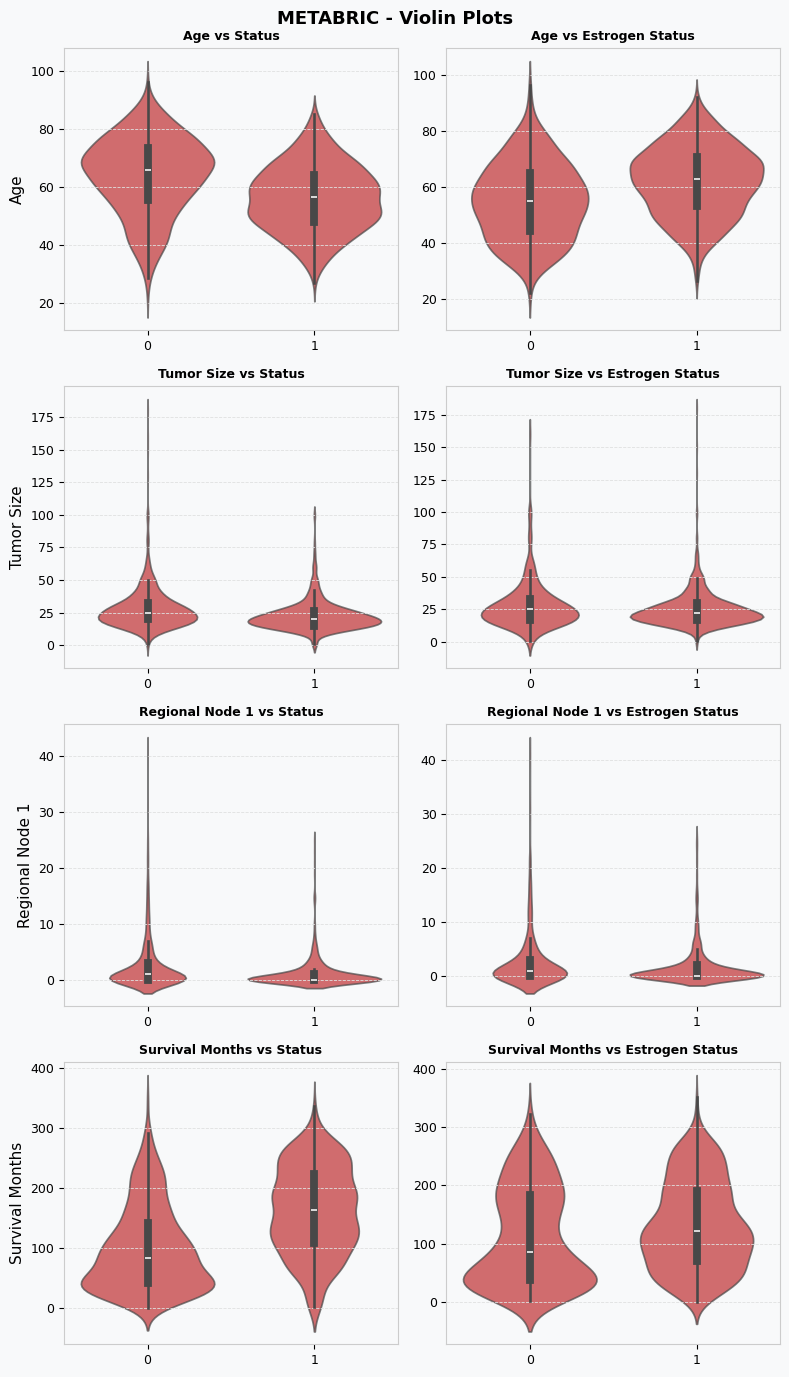

In [13]:
plot_violins(metabric, cat_vars, num_vars, 'METABRIC', PALETTE['METABRIC'])

**METABRIC key observations:**
- Regional nodes are concentrated near 0 for both Status groups — less discriminatory than in SEER
- Estrogen-positive patients tend to survive longer (median > 100 months vs < 100 for negative)
- Tumor size vs Status pattern mirrors SEER: survivors cluster around 12-15mm

---
## 7. Key Takeaways

| Finding | SEER | METABRIC |
|---|---|---|
| Strongest Status correlate | Regional Node (-0.26) | Age (-0.29) |
| Estrogen positive rate | 93% | 77% |
| Alive proportion | 85% | 44% |
| Collinearity risk | T Stage <-> Tumor Size (0.81) | T Stage <-> Tumor Size (0.52) |
| Survival window | Max 107 months | Max 351 months |

These observations motivate the three hypotheses tested in **Notebook 2**:
- H1: Does the regional node effect on survival months differ by population?
- H2: Does estrogen receptor status affect survival differently across populations?
- H3: Does splitting patients by tumour size (>50mm) improve status prediction?